# Results analysis — EEG-only vs. EEG+ECG seizure prediction

Compares the two feature sets on the **SeizeIT2** dataset (seizure **prediction**: pre-ictal vs.
interictal, within-subject 60/20/20 split). This notebook only **compares** the two models on the
held-out **test** set — training/evaluation happen in the `train_model_*` / `evaluate_*` scripts.

The **headline metric is the per-subject AUC** (within-patient ranking quality), not the
global/pooled AUC: because the model's probability scale differs per patient, pooling all
subjects together destroys the ranking and makes the global AUC look like chance. The
per-subject AUC is the honest measure of whether the model has real signal.

Inputs (produced by `evaluate_eeg.py --eval-split test` / `evaluate_eeg_ecg.py --eval-split test`):
- `../results/seizure_prediction_<eeg|eeg_ecg>/test/per_subject.csv` — per-subject metrics (final ensemble)
- `../results/seizure_prediction_<eeg|eeg_ecg>/test/metrics.csv` — global metrics: 5 seed rows + ensemble

All comparison output (figures + `comparison_summary.txt`) is written to `../results/comparison/<timestamp>/`.

In [1]:
import csv
from datetime import datetime
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULTS = Path('../results')
SPLIT = 'test'   # compare the held-out TEST results of each model (final, one-time)
PIPELINES = {
    'eeg':     RESULTS / 'seizure_prediction_eeg' / SPLIT,
    'eeg_ecg': RESULTS / 'seizure_prediction_eeg_ecg' / SPLIT,
}

# All comparison output (figures + summary) goes to a timestamped directory,
# so every notebook run is preserved separately.
OUT_DIR = RESULTS / 'comparison' / datetime.now().strftime('%Y%m%d_%H%M%S')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Reading {SPLIT} results from:')
for fs, p in PIPELINES.items():
    print(f'  {fs:8} -> {p}  ({"OK" if (p / "per_subject.csv").exists() else "MISSING"})')
print(f'Output directory: {OUT_DIR.resolve()}')

Reading test results from:
  eeg      -> ..\results\seizure_prediction_eeg\test  (OK)
  eeg_ecg  -> ..\results\seizure_prediction_eeg_ecg\test  (OK)
Output directory: C:\Users\yordi\Desktop\capstone-project\results\comparison\20260615_195003


In [2]:
# Load per-subject AUC for each feature set (subject -> AUC, or None if no test positives).
def load_per_subject(feature_set):
    p = PIPELINES[feature_set] / 'per_subject.csv'
    out = {}
    if p.exists():
        with open(p, newline='', encoding='utf-8') as f:
            for r in csv.DictReader(f):
                out[r['subject']] = (float(r['auc']) if r['auc'] not in ('', 'nan') else None)
    else:
        print(f'WARNING: {p} not found - run evaluate_{feature_set}.py first.')
    return out

auc_eeg = load_per_subject('eeg')
auc_ecg = load_per_subject('eeg_ecg')
print(f'eeg: {len(auc_eeg)} subjects | eeg_ecg: {len(auc_ecg)} subjects')

eeg: 60 subjects | eeg_ecg: 56 subjects


In [3]:
# Paired per-subject comparison (subjects with an AUC in BOTH feature sets).
subjects = sorted(set(auc_eeg) | set(auc_ecg))
paired = [(s, auc_eeg.get(s), auc_ecg.get(s)) for s in subjects
          if auc_eeg.get(s) is not None and auc_ecg.get(s) is not None]

print('Per-subject within-patient AUC:')
print(f"  {'subject':10}{'EEG':>8}{'EEG+ECG':>10}{'delta':>9}")
for s, a, b in paired:
    print(f'  {s:10}{a:>8.3f}{b:>10.3f}{b - a:>+9.3f}')

e = np.array([a for _, a, _ in paired])
c = np.array([b for _, _, b in paired])
if len(paired):
    print('\nMean per-subject AUC:')
    print(f'  EEG     : {e.mean():.3f} +/- {e.std():.3f}')
    print(f'  EEG+ECG : {c.mean():.3f} +/- {c.std():.3f}')
    verdict = 'ECG helps' if (c - e).mean() > 0 else 'ECG does not help'
    print(f'  Mean delta (EEG+ECG - EEG): {(c - e).mean():+.3f}  ({verdict} on average)')

Per-subject within-patient AUC:
  subject        EEG   EEG+ECG    delta
  sub-001      0.517     0.637   +0.120
  sub-002      0.430     0.441   +0.011
  sub-003      0.322     0.357   +0.035
  sub-004      0.067     0.095   +0.028
  sub-005      0.802     0.717   -0.085
  sub-006      0.193     0.414   +0.221
  sub-007      0.450     0.461   +0.012
  sub-008      0.527     0.553   +0.026
  sub-009      0.430     0.728   +0.298
  sub-010      0.539     0.441   -0.098
  sub-011      0.585     0.484   -0.102
  sub-012      0.252     0.630   +0.378
  sub-013      0.427     0.723   +0.295
  sub-014      0.655     0.827   +0.173
  sub-015      0.705     0.599   -0.106
  sub-016      0.374     0.972   +0.598
  sub-017      0.127     0.140   +0.013
  sub-018      0.852     0.775   -0.076
  sub-019      0.593     0.531   -0.062
  sub-020      0.323     0.916   +0.593
  sub-021      0.625     0.565   -0.061
  sub-022      0.332     0.400   +0.068
  sub-023      0.112     0.301   +0.189
  sub-02

Saved C:\Users\yordi\Desktop\capstone-project\results\comparison\20260615_195003\comparison_eeg_vs_eeg_ecg.png


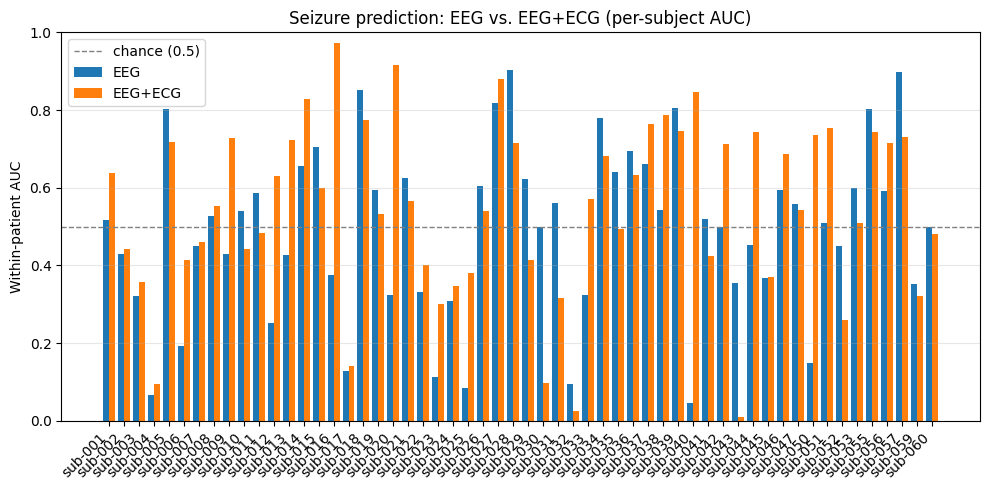

In [4]:
# Comparison figure: per-subject AUC, EEG vs EEG+ECG.
x = np.arange(len(paired))
w = 0.4
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, [a for _, a, _ in paired], w, label='EEG')
ax.bar(x + w / 2, [b for _, _, b in paired], w, label='EEG+ECG')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels([s for s, _, _ in paired], rotation=45, ha='right')
ax.set_ylabel('Within-patient AUC')
ax.set_ylim(0, 1)
ax.set_title('Seizure prediction: EEG vs. EEG+ECG (per-subject AUC)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'comparison_eeg_vs_eeg_ecg.png', dpi=150)
print('Saved', (OUT_DIR / 'comparison_eeg_vs_eeg_ecg.png').resolve())
plt.show()

In [5]:
# Global metrics (latest run per feature set) - the pooled AUC is contaminated,
# shown for completeness only. F1 is at threshold 0.5.
def latest_global(feature_set):
    p = PIPELINES[feature_set] / 'metrics.csv'
    if not p.exists():
        return None
    with open(p, newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
    return rows[-1] if rows else None

print(f"{'feature_set':12}{'F1':>8}{'AUC-ROC':>10}{'AUC-PR':>9}{'train_f1':>10}")
print('-' * 49)
for fs in ('eeg', 'eeg_ecg'):
    r = latest_global(fs)
    if r:
        print(f"{fs:12}{float(r['f1']):>8.3f}{float(r['auc_roc']):>10.3f}"
              f"{float(r['auc_pr']):>9.3f}{float(r['train_f1']):>10.3f}")
    else:
        print(f'{fs:12}  (no metrics.csv yet)')

feature_set       F1   AUC-ROC   AUC-PR  train_f1
-------------------------------------------------
eeg            0.307     0.581    0.201     0.311
eeg_ecg        0.311     0.579    0.212     0.443


In [6]:
# ── Multi-seed robustness: mean ± std over the 5 independently-seeded runs ──
# metrics.csv per arm holds 5 seed rows (n_runs=1) + the final ensemble (n_runs=5).
# The seed spread is the key statistical check: is the EEG -> EEG+ECG difference
# bigger than the run-to-run noise? This is written to comparison_summary.txt.
def load_metric_rows(feature_set):
    p = PIPELINES[feature_set] / 'metrics.csv'
    if not p.exists():
        return []
    with open(p, newline='', encoding='utf-8') as f:
        return list(csv.DictReader(f))

def split_seed_ensemble(rows):
    seeds = [r for r in rows if r.get('n_runs', '1') == '1']
    ens   = [r for r in rows if r.get('n_runs', '1') not in ('1', '', None)]
    return seeds, (ens[-1] if ens else (rows[-1] if rows else None))

def col(rows, key):
    return np.array([float(r[key]) for r in rows
                     if r.get(key) not in (None, '', 'nan')])

SUMMARY_METRICS = [
    ('auc_roc',              'pooled AUC-ROC'),
    ('mean_subj_auc',        'mean per-subject AUC'),
    ('mean_subj_auc_smooth', 'mean per-subj AUC (smoothed)'),
    ('f1',                   'F1 (thr 0.5)'),
]

seeds_eeg, ens_eeg = split_seed_ensemble(load_metric_rows('eeg'))
seeds_ecg, ens_ecg = split_seed_ensemble(load_metric_rows('eeg_ecg'))

lines = [f'EEG vs EEG+ECG  |  split={SPLIT.upper()}  |  '
         f'{len(seeds_eeg)} seeds + final ensemble', '',
         f"{'metric':<30}{'EEG (mean±std)':>18}{'EEG+ECG (mean±std)':>20}{'Δ':>9}",
         '-' * 77]
for key, label in SUMMARY_METRICS:
    e, c = col(seeds_eeg, key), col(seeds_ecg, key)
    if len(e) and len(c):
        lines.append(f'{label:<30}{e.mean():>8.3f}±{e.std():<8.3f}'
                     f'{c.mean():>9.3f}±{c.std():<9.3f}{c.mean()-e.mean():>+9.3f}')
lines += ['', 'Final ensemble (single point estimate):']
for key, label in SUMMARY_METRICS:
    ve = float(ens_eeg[key]) if ens_eeg and ens_eeg.get(key) not in (None, '', 'nan') else float('nan')
    vc = float(ens_ecg[key]) if ens_ecg and ens_ecg.get(key) not in (None, '', 'nan') else float('nan')
    lines.append(f'  {label:<28}EEG {ve:>7.3f}   EEG+ECG {vc:>7.3f}   Δ {vc-ve:>+7.3f}')
lines += ['', 'Δ = EEG+ECG − EEG   (positive = ECG helps)']

summary = '\n'.join(lines)
print(summary)
(OUT_DIR / 'comparison_summary.txt').write_text(summary + '\n', encoding='utf-8')
print('\nSaved ->', (OUT_DIR / 'comparison_summary.txt').resolve())

EEG vs EEG+ECG  |  split=TEST  |  6 seeds + final ensemble

metric                            EEG (mean±std)  EEG+ECG (mean±std)        Δ
-----------------------------------------------------------------------------
pooled AUC-ROC                   0.580±0.005       0.573±0.007       -0.007
mean per-subject AUC             0.500±0.015       0.521±0.017       +0.021
mean per-subj AUC (smoothed)     0.523±0.022       0.547±0.026       +0.024
F1 (thr 0.5)                     0.307±0.002       0.293±0.010       -0.014

Final ensemble (single point estimate):
  pooled AUC-ROC              EEG   0.586   EEG+ECG   0.576   Δ  -0.010
  mean per-subject AUC        EEG   0.497   EEG+ECG   0.519   Δ  +0.022
  mean per-subj AUC (smoothed)EEG   0.521   EEG+ECG   0.545   Δ  +0.023
  F1 (thr 0.5)                EEG   0.310   EEG+ECG   0.289   Δ  -0.021

Δ = EEG+ECG − EEG   (positive = ECG helps)

Saved -> C:\Users\yordi\Desktop\capstone-project\results\comparison\20260615_195003\comparison_summary.txt

---
## Extended comparative analysis: EEG only vs EEG + ECG

The following sections give a complete picture of what adding ECG data does:
- **Global metrics** – all scores side by side as a bar chart
- **Per-subject F1** – besides AUC, the F1 score per patient compared
- **AUC delta** – for which patients does ECG help, and by how much?
- **AUC scatter** – EEG vs EEG+ECG per patient, with the diagonal as reference
- **Confusion matrices** – normalised heatmaps side by side
- **Threshold sweep** – P/R/F1 across thresholds for both models
- **Summary heatmap** – all metrics × all patients at a glance

In [1]:
import re
import matplotlib.patches as mpatches

C_EEG = '#2196F3'
C_ECG = '#FF6B35'
C_POS = '#27AE60'
C_NEG = '#E74C3C'

def load_per_subject_full(feature_set):
    """Returns dict {subject: {auc, f1, precision, recall, n_preictal, n_test}}."""
    p = PIPELINES[feature_set] / 'per_subject.csv'
    out = {}
    if not p.exists():
        print(f'WARNING: {p} not found')
        return out
    with open(p, newline='', encoding='utf-8') as f:
        for r in csv.DictReader(f):
            out[r['subject']] = {
                k: (float(v) if v not in ('', 'nan') else float('nan'))
                for k, v in r.items() if k not in ('feature_set', 'subject')
            }
    return out

def latest_report_path(feature_set):
    reports_dir = PIPELINES[feature_set] / 'reports'
    files = sorted(reports_dir.glob(f'eval_{feature_set}_*.txt'))
    return files[-1] if files else None

def parse_report_extras(report_path):
    """Extracts specificity, balanced_acc and train_f1_gap from the report txt."""
    if report_path is None:
        return {}
    text = report_path.read_text(encoding='utf-8')
    out = {}
    for key, pat in [
        ('specificity',  r'Specificity\s+:\s+([\d.]+)'),
        ('balanced_acc', r'Balanced acc\s+:\s+([\d.]+)'),
        ('gap',          r'gap\s+([+-][\d.]+)'),
    ]:
        m = re.search(pat, text)
        if m:
            out[key] = float(m.group(1))
    return out

def parse_threshold_sweep(report_path):
    if report_path is None:
        return []
    text = report_path.read_text(encoding='utf-8')
    rows = []
    for line in text.splitlines():
        m = re.match(r'\s+thr\s+(\d\.\d):\s+P\s+([\d.]+)\s+R\s+([\d.]+)\s+F1\s+([\d.]+)', line)
        if m:
            rows.append({'thr': float(m.group(1)), 'precision': float(m.group(2)),
                         'recall': float(m.group(3)), 'f1': float(m.group(4))})
    return rows

# --- load everything ---
ps_eeg = load_per_subject_full('eeg')
ps_ecg = load_per_subject_full('eeg_ecg')
gm_eeg = latest_global('eeg')
gm_ecg = latest_global('eeg_ecg')
ex_eeg = parse_report_extras(latest_report_path('eeg'))
ex_ecg = parse_report_extras(latest_report_path('eeg_ecg'))
sw_eeg = parse_threshold_sweep(latest_report_path('eeg'))
sw_ecg = parse_threshold_sweep(latest_report_path('eeg_ecg'))

ALL_SUBJ = sorted(set(ps_eeg) | set(ps_ecg))
print(f'Subjects: {len(ALL_SUBJ)}  |  EEG runs: {len(ps_eeg)}  |  EEG+ECG runs: {len(ps_ecg)}')

NameError: name 'PIPELINES' is not defined

### 1. Global metrics comparison

In [2]:
metrics_def = [
    ('AUC-ROC',     'auc_roc',  None,         None),
    ('AUC-PR',      'auc_pr',   None,         None),
    ('F1',          'f1',       None,         None),
    ('Precision',   'precision',None,         None),
    ('Recall',      'recall',   None,         None),
    ('Specificity', None,       'specificity','specificity'),
    ('Balanced Acc',None,       'balanced_acc','balanced_acc'),
]

labels   = [m[0] for m in metrics_def]
vals_eeg = []
vals_ecg = []
for _, csv_key, ex_key_e, ex_key_c in metrics_def:
    ve = float(gm_eeg[csv_key]) if csv_key and gm_eeg else ex_eeg.get(ex_key_e, float('nan'))
    vc = float(gm_ecg[csv_key]) if csv_key and gm_ecg else ex_ecg.get(ex_key_c, float('nan'))
    if csv_key is None:
        ve = ex_eeg.get(ex_key_e, float('nan'))
        vc = ex_ecg.get(ex_key_c, float('nan'))
    vals_eeg.append(ve)
    vals_ecg.append(vc)

vals_eeg = np.array(vals_eeg)
vals_ecg = np.array(vals_ecg)
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, vals_eeg, w, label='EEG only',  color=C_EEG, alpha=0.88)
b2 = ax.bar(x + w/2, vals_ecg, w, label='EEG + ECG', color=C_ECG, alpha=0.88)

for bar in [*b1, *b2]:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.axhline(0.5, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='Chance (0.50)')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.0); ax.set_ylabel('Score')
ax.set_title('Global metrics: EEG only  vs  EEG + ECG', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'comparison_global_metrics.png', dpi=150)
plt.show()

NameError: name 'gm_eeg' is not defined

### 2. Per-subject F1 comparison

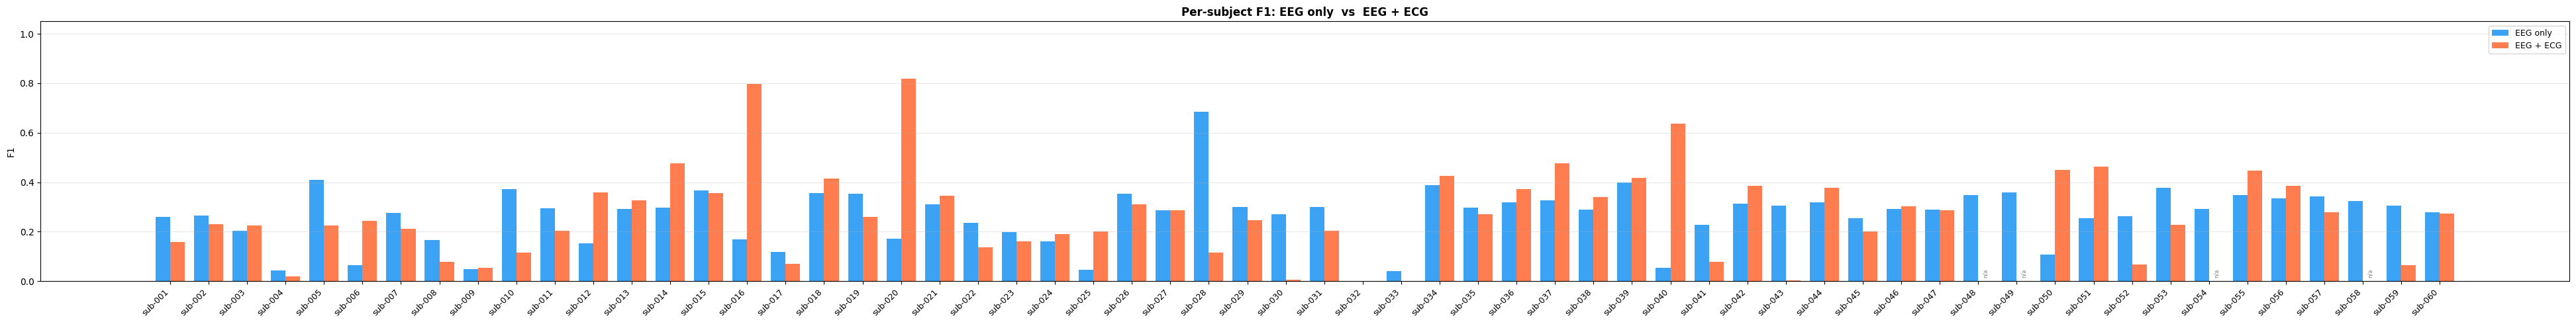

In [9]:
def plot_per_subject_metric(metric, ylabel, save_name):
    f_eeg = np.array([ps_eeg.get(s, {}).get(metric, float('nan')) for s in ALL_SUBJ])
    f_ecg = np.array([ps_ecg.get(s, {}).get(metric, float('nan')) for s in ALL_SUBJ])
    x = np.arange(len(ALL_SUBJ))
    w = 0.38

    fig, ax = plt.subplots(figsize=(max(10, len(ALL_SUBJ)*0.65), 5))
    ax.bar(x - w/2, np.nan_to_num(f_eeg), w, label='EEG only',  color=C_EEG, alpha=0.88)
    ax.bar(x + w/2, np.nan_to_num(f_ecg), w, label='EEG + ECG', color=C_ECG, alpha=0.88)

    for i, (ve, vc) in enumerate(zip(f_eeg, f_ecg)):
        if np.isnan(ve):
            ax.text(x[i]-w/2, 0.015, 'n/a', ha='center', va='bottom',
                    fontsize=6, color='gray', rotation=90)
        if np.isnan(vc):
            ax.text(x[i]+w/2, 0.015, 'n/a', ha='center', va='bottom',
                    fontsize=6, color='gray', rotation=90)

    if metric == 'auc':
        ax.axhline(0.5, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='Chance (0.50)')
    ax.set_xticks(x); ax.set_xticklabels(ALL_SUBJ, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel(ylabel)
    ax.set_title(f'Per-subject {ylabel}: EEG only  vs  EEG + ECG', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / save_name, dpi=150)
    plt.show()

plot_per_subject_metric('f1', 'F1', 'comparison_per_subject_f1.png')

### 3. AUC delta per subject  
Positive = ECG improves the ranking, negative = ECG harms it.

ECG improves AUC for 30/56 subjects  (mean delta +0.058)


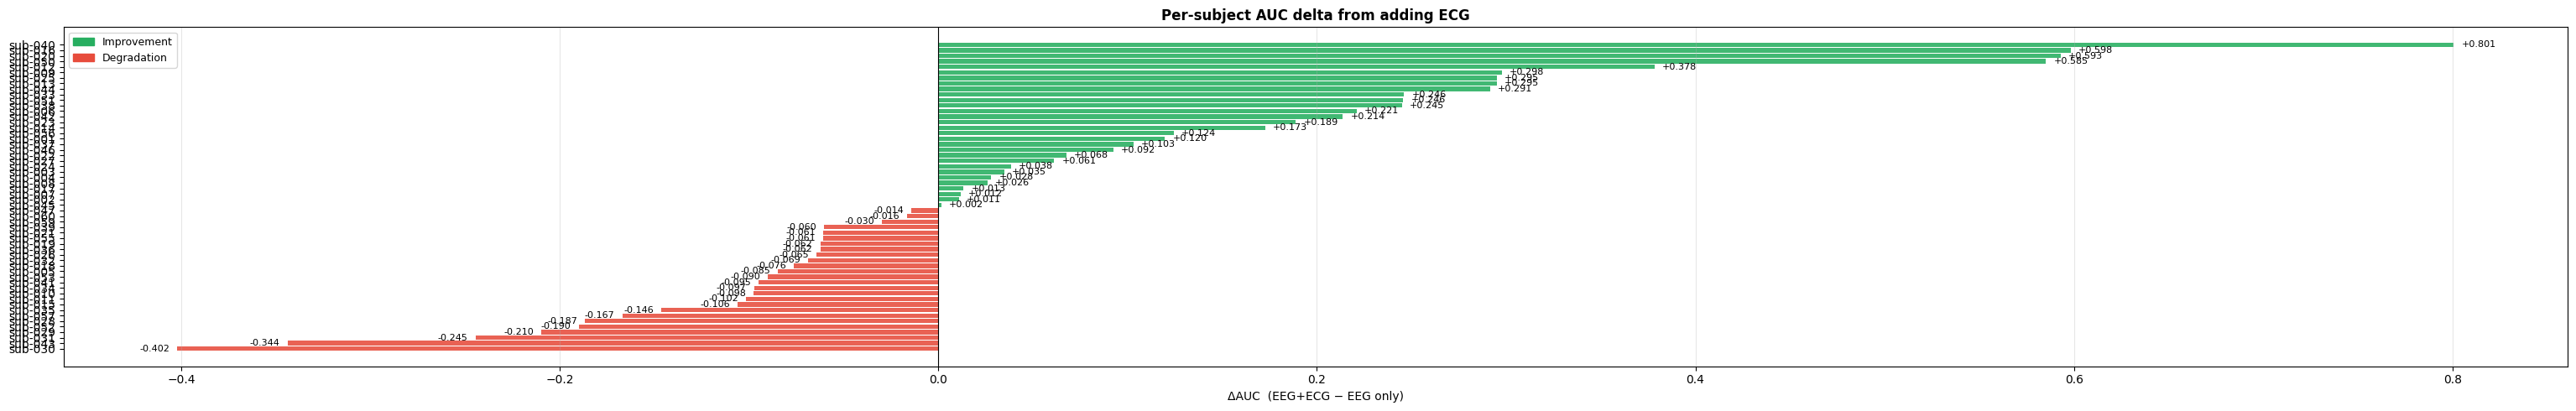

In [10]:
deltas, delta_labels = [], []
for s in ALL_SUBJ:
    ae = ps_eeg.get(s, {}).get('auc', float('nan'))
    ac = ps_ecg.get(s, {}).get('auc', float('nan'))
    if not (np.isnan(ae) or np.isnan(ac)):
        deltas.append(ac - ae)
        delta_labels.append(s)

order = np.argsort(deltas)
deltas       = [deltas[i]       for i in order]
delta_labels = [delta_labels[i] for i in order]
colors = [C_POS if d >= 0 else C_NEG for d in deltas]

fig, ax = plt.subplots(figsize=(max(8, len(delta_labels)*0.55), 5))
bars = ax.barh(delta_labels, deltas, color=colors, alpha=0.88)
ax.axvline(0, color='black', linewidth=0.8)

for bar, d in zip(bars, deltas):
    ax.text(d + (0.004 if d >= 0 else -0.004),
            bar.get_y() + bar.get_height()/2,
            f'{d:+.3f}', va='center',
            ha='left' if d >= 0 else 'right', fontsize=8)

ax.set_xlabel('ΔAUC  (EEG+ECG − EEG only)')
ax.set_title('Per-subject AUC delta from adding ECG', fontsize=12, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=C_POS, label='Improvement'),
                   mpatches.Patch(color=C_NEG, label='Degradation')], fontsize=9)
ax.grid(axis='x', alpha=0.3)
n_pos = sum(d > 0 for d in deltas)
print(f'ECG improves AUC for {n_pos}/{len(deltas)} subjects  '
      f'(mean delta {np.mean(deltas):+.3f})')
fig.tight_layout()
fig.savefig(OUT_DIR / 'comparison_auc_delta.png', dpi=150)
plt.show()

### 4. Scatter: EEG AUC vs EEG+ECG AUC per subject  
Points above the diagonal → ECG helps that patient.

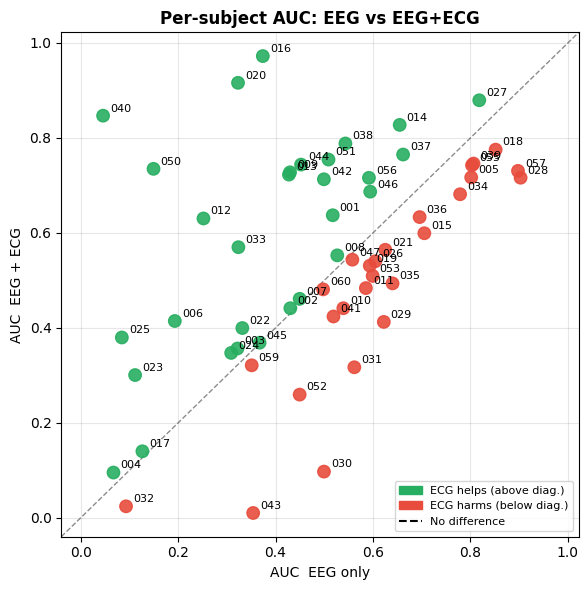

In [11]:
xs, ys, sc_labels = [], [], []
for s in ALL_SUBJ:
    ae = ps_eeg.get(s, {}).get('auc', float('nan'))
    ac = ps_ecg.get(s, {}).get('auc', float('nan'))
    if not (np.isnan(ae) or np.isnan(ac)):
        xs.append(ae); ys.append(ac)
        sc_labels.append(s.replace('sub-', ''))

xs, ys = np.array(xs), np.array(ys)
sc_colors = [C_POS if y > x else C_NEG for x, y in zip(xs, ys)]

lo = min(xs.min(), ys.min()) - 0.05
hi = max(xs.max(), ys.max()) + 0.05

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.45, label='No difference')
ax.scatter(xs, ys, c=sc_colors, s=80, zorder=3, alpha=0.9)
for x_, y_, lab in zip(xs, ys, sc_labels):
    ax.annotate(lab, (x_, y_), textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('AUC  EEG only', fontsize=10)
ax.set_ylabel('AUC  EEG + ECG', fontsize=10)
ax.set_title('Per-subject AUC: EEG vs EEG+ECG', fontsize=12, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=C_POS, label='ECG helps (above diag.)'),
                   mpatches.Patch(color=C_NEG, label='ECG harms (below diag.)'),
                   plt.Line2D([0],[0], color='k', linestyle='--', label='No difference')],
          fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'comparison_scatter_auc.png', dpi=150)
plt.show()

### 5. Confusion matrices (normalised)

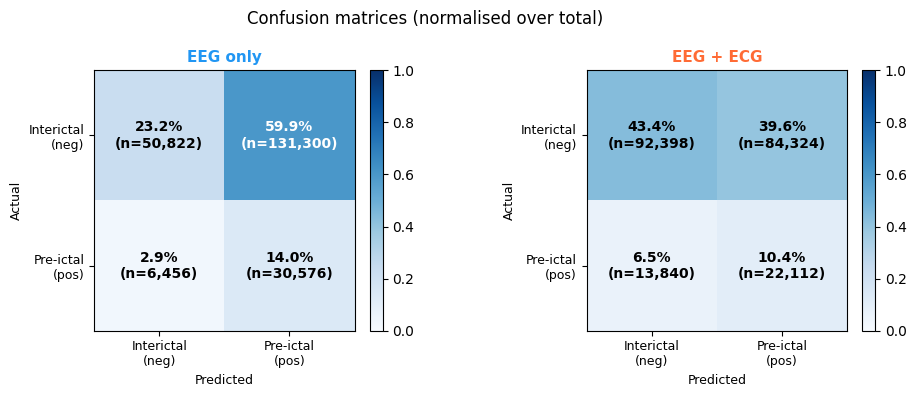

In [12]:
def _cm_array(m):
    return np.array([[int(m['tn']), int(m['fp'])],
                     [int(m['fn']), int(m['tp'])]])

tick_labels = ['Interictal\n(neg)', 'Pre-ictal\n(pos)']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, cm_raw, color) in zip(axes, [
    ('EEG only',  _cm_array(gm_eeg), C_EEG),
    ('EEG + ECG', _cm_array(gm_ecg), C_ECG),
]):
    total = cm_raw.sum()
    norm  = cm_raw / total
    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(2):
        for j in range(2):
            txt_c = 'white' if norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{norm[i,j]*100:.1f}%\n(n={cm_raw[i,j]:,})',
                    ha='center', va='center', fontsize=10,
                    color=txt_c, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_yticklabels(tick_labels, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)

fig.suptitle('Confusion matrices (normalised over total)', fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'comparison_confusion_matrices.png', dpi=150)
plt.show()

### 6. Threshold sweep: Precision / Recall / F1  
Shows how the trade-off shifts at different thresholds.

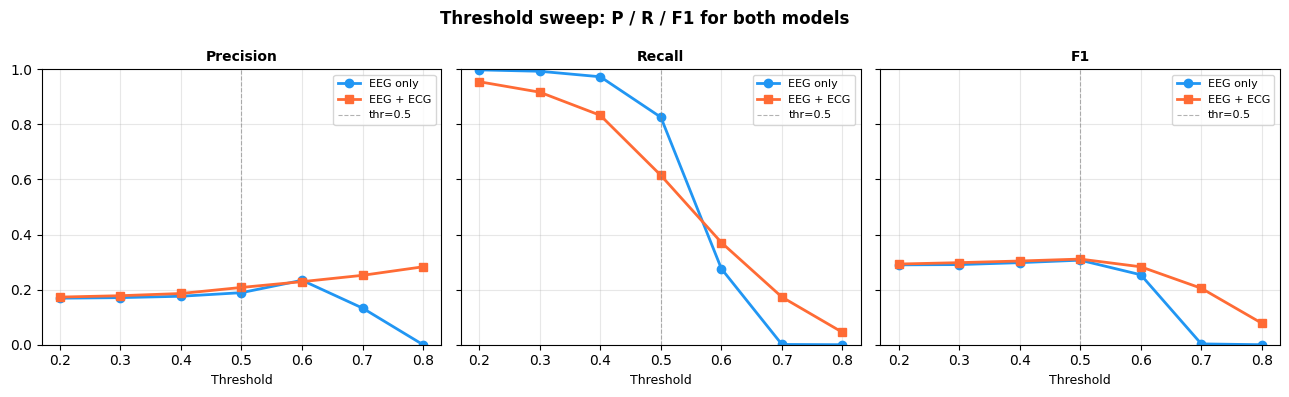

In [13]:
if sw_eeg and sw_ecg:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    metric_keys  = ['precision', 'recall', 'f1']
    metric_names = ['Precision', 'Recall', 'F1']

    t_e = [r['thr'] for r in sw_eeg]
    t_c = [r['thr'] for r in sw_ecg]

    for ax, key, name in zip(axes, metric_keys, metric_names):
        ax.plot(t_e, [r[key] for r in sw_eeg], 'o-', color=C_EEG, linewidth=2, label='EEG only')
        ax.plot(t_c, [r[key] for r in sw_ecg], 's-', color=C_ECG, linewidth=2, label='EEG + ECG')
        ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6, label='thr=0.5')
        ax.set_xlabel('Threshold', fontsize=9)
        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.0); ax.grid(alpha=0.3); ax.legend(fontsize=8)

    fig.suptitle('Threshold sweep: P / R / F1 for both models', fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'comparison_threshold_sweep.png', dpi=150)
    plt.show()
else:
    print('No threshold sweep data available (report files not found).')

### 7. Summary heatmap: all subjects × all metrics  
Left panel = EEG only, middle = EEG+ECG, right = delta (green = better with ECG).

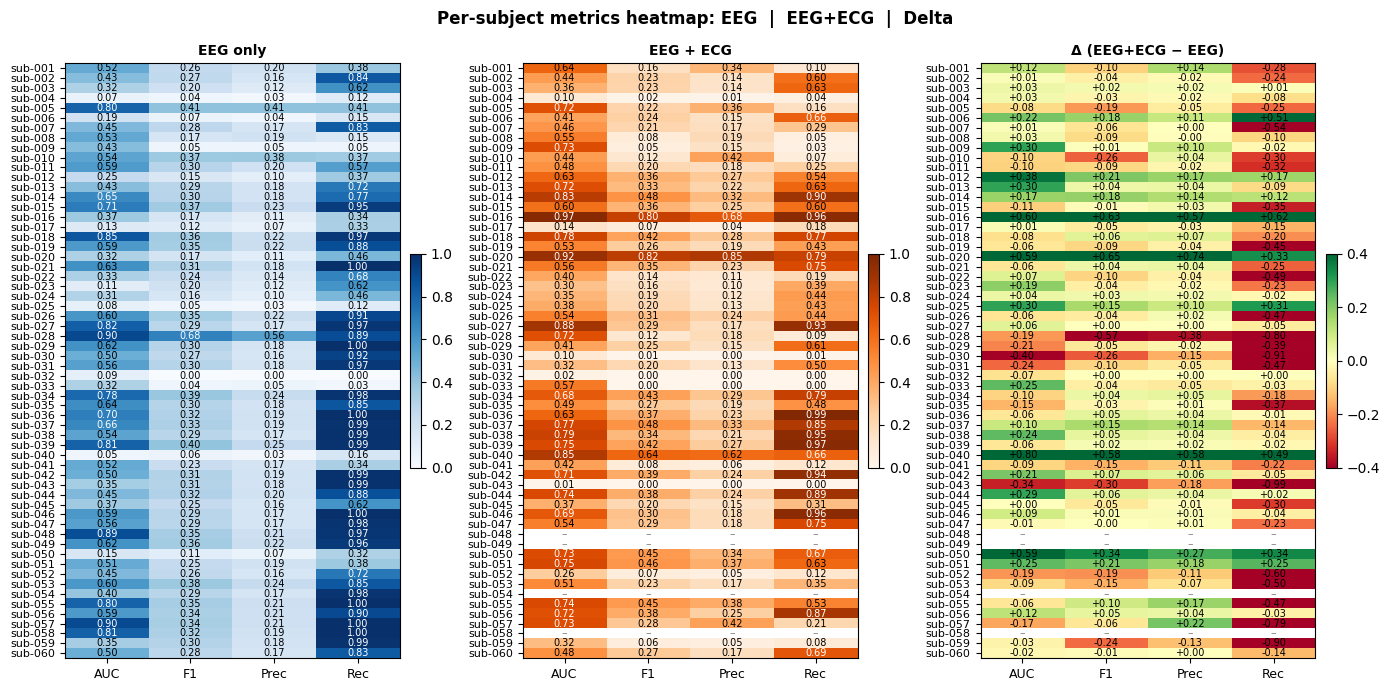


All figures saved to: C:\Users\yordi\Desktop\capstone-project\results\comparison\20260615_195003


In [14]:
hm_metrics = ['auc', 'f1', 'precision', 'recall']
hm_labels  = ['AUC', 'F1', 'Prec', 'Rec']

eeg_arr = np.array([[ps_eeg.get(s, {}).get(k, float('nan')) for k in hm_metrics]
                    for s in ALL_SUBJ])
ecg_arr = np.array([[ps_ecg.get(s, {}).get(k, float('nan')) for k in hm_metrics]
                    for s in ALL_SUBJ])
delta_arr = ecg_arr - eeg_arr

fig, axes = plt.subplots(1, 3, figsize=(14, 7))
panels = [
    (axes[0], eeg_arr,   'EEG only',          'Blues',   0.0,  1.0),
    (axes[1], ecg_arr,   'EEG + ECG',         'Oranges', 0.0,  1.0),
    (axes[2], delta_arr, 'Δ (EEG+ECG − EEG)', 'RdYlGn', -0.4, 0.4),
]

for ax, data, title, cmap, vmin, vmax in panels:
    masked = np.ma.masked_invalid(data)
    im = ax.imshow(masked, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
    for i in range(len(ALL_SUBJ)):
        for j in range(len(hm_metrics)):
            val = data[i, j]
            if not np.isnan(val):
                is_delta = (vmin < 0)
                txt_c = 'white' if (not is_delta and val > 0.65) else 'black'
                fmt = f'{val:+.2f}' if is_delta else f'{val:.2f}'
                ax.text(j, i, fmt, ha='center', va='center', fontsize=7, color=txt_c)
            else:
                ax.text(j, i, '–', ha='center', va='center', fontsize=8, color='gray')
    ax.set_xticks(range(len(hm_metrics))); ax.set_xticklabels(hm_labels, fontsize=9)
    ax.set_yticks(range(len(ALL_SUBJ)));   ax.set_yticklabels(ALL_SUBJ, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')

fig.suptitle('Per-subject metrics heatmap: EEG  |  EEG+ECG  |  Delta',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR / 'comparison_summary_heatmap.png', dpi=150)
plt.show()

print(f'\nAll figures saved to: {OUT_DIR.resolve()}')